<a href="https://colab.research.google.com/github/royarka251/UPI--Fraud---Prediction/blob/main/UPI_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving PS_20174392719_1491204439457_log.csv to PS_20174392719_1491204439457_log.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.shape

(6362620, 11)

In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [9]:
df = df[['step',
         'type',
         'amount',
         'oldbalanceOrg',
         'newbalanceOrig',
         'oldbalanceDest',
         'newbalanceDest',
         'isFraud']]

In [10]:
encoder = LabelEncoder()

df['type'] = encoder.fit_transform(df['type'])

In [11]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1
3,1,1,181.00,181.0,0.00,21182.0,0.0,1
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0


In [12]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [5]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [7]:
df.shape

(6362620, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [12]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


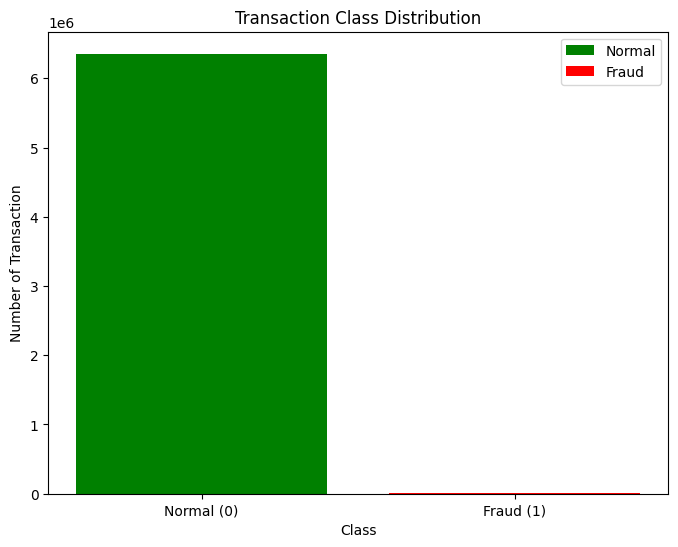

In [14]:
class_counts = df['isFraud'].value_counts()
labels = ['Normal (0)', 'Fraud (1)']
plt.figure(figsize=(8, 6))
bars=plt.bar(labels, class_counts, color=['green', 'red'], label=['Normal', 'Fraud'])
plt.title("Transaction Class Distribution")
plt.xlabel('Class')
plt.ylabel('Number of Transaction')
plt.legend()
plt.show()

In [15]:
X = df.drop("isFraud", axis='columns')
y = df["isFraud"]

In [16]:
X = df.drop("isFraud", axis='columns')
y = df["isFraud"]

In [17]:
X.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [18]:
X = X.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [19]:
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0


In [20]:
X = pd.get_dummies(X, columns=['type'], drop_first=True)

In [21]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,True,False


In [22]:
smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)

In [23]:
X_sm.value_counts()

step  amount        oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER
387   1.000000e+07  1.000000e+07   0.0             0.000000e+00    1.000000e+07    True           False       False         False            1891
617   1.000000e+07  1.000000e+07   0.0             0.000000e+00    1.000000e+07    True           False       False         False            1847
646   1.000000e+07  1.000000e+07   0.0             0.000000e+00    1.000000e+07    True           False       False         False             973
645   1.000000e+07  1.000000e+07   0.0             0.000000e+00    1.000000e+07    True           False       False         False             944
730   1.000000e+07  1.000000e+07   0.0             0.000000e+00    1.000000e+07    True           False       False         False             540
                                                                                                                                             ... 
214   4.530531e+05  4.530531e+05   0.0             4.608301e+04    4.991361e+05    True           False       False         False               1
      4.530736e+05  4.530736e+05   0.0             4.608621e+04    4.991598e+05    True           False       False         False               1
      4.530863e+05  4.530863e+05   0.0             4.608820e+04    4.991745e+05    True           False       False         False               1
      4.531345e+05  0.000000e+00   0.0             5.598202e+06    6.051337e+06    False          False       False         True                1
      4.523665e+05  4.523665e+05   0.0             0.000000e+00    0.000000e+00    False          False       False         True                1
Name: count, Length: 12664691, dtype: int64

In [24]:
X_sm.shape

(12708814, 10)

In [25]:
X_sm.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,True,False


In [26]:
y_sm.value_counts()

,count
isFraud,
0,6354407
1,6354407


In [27]:
y_sm.shape

(12708814,)

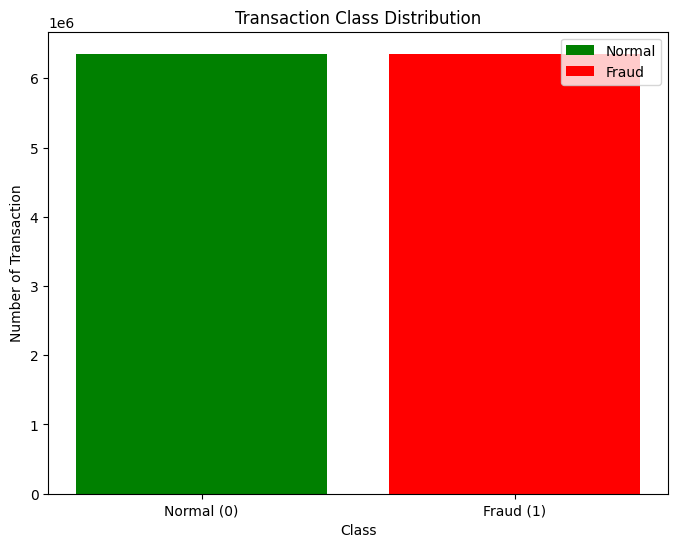

In [28]:
class_counts = y_sm.value_counts()
labels = ['Normal (0)', 'Fraud (1)']
plt.figure(figsize=(8, 6))
bars=plt.bar(labels, class_counts, color=['green', 'red'], label=['Normal', 'Fraud'])
plt.title("Transaction Class Distribution")
plt.xlabel('Class')
plt.ylabel('Number of Transaction')
plt.legend()
plt.show()

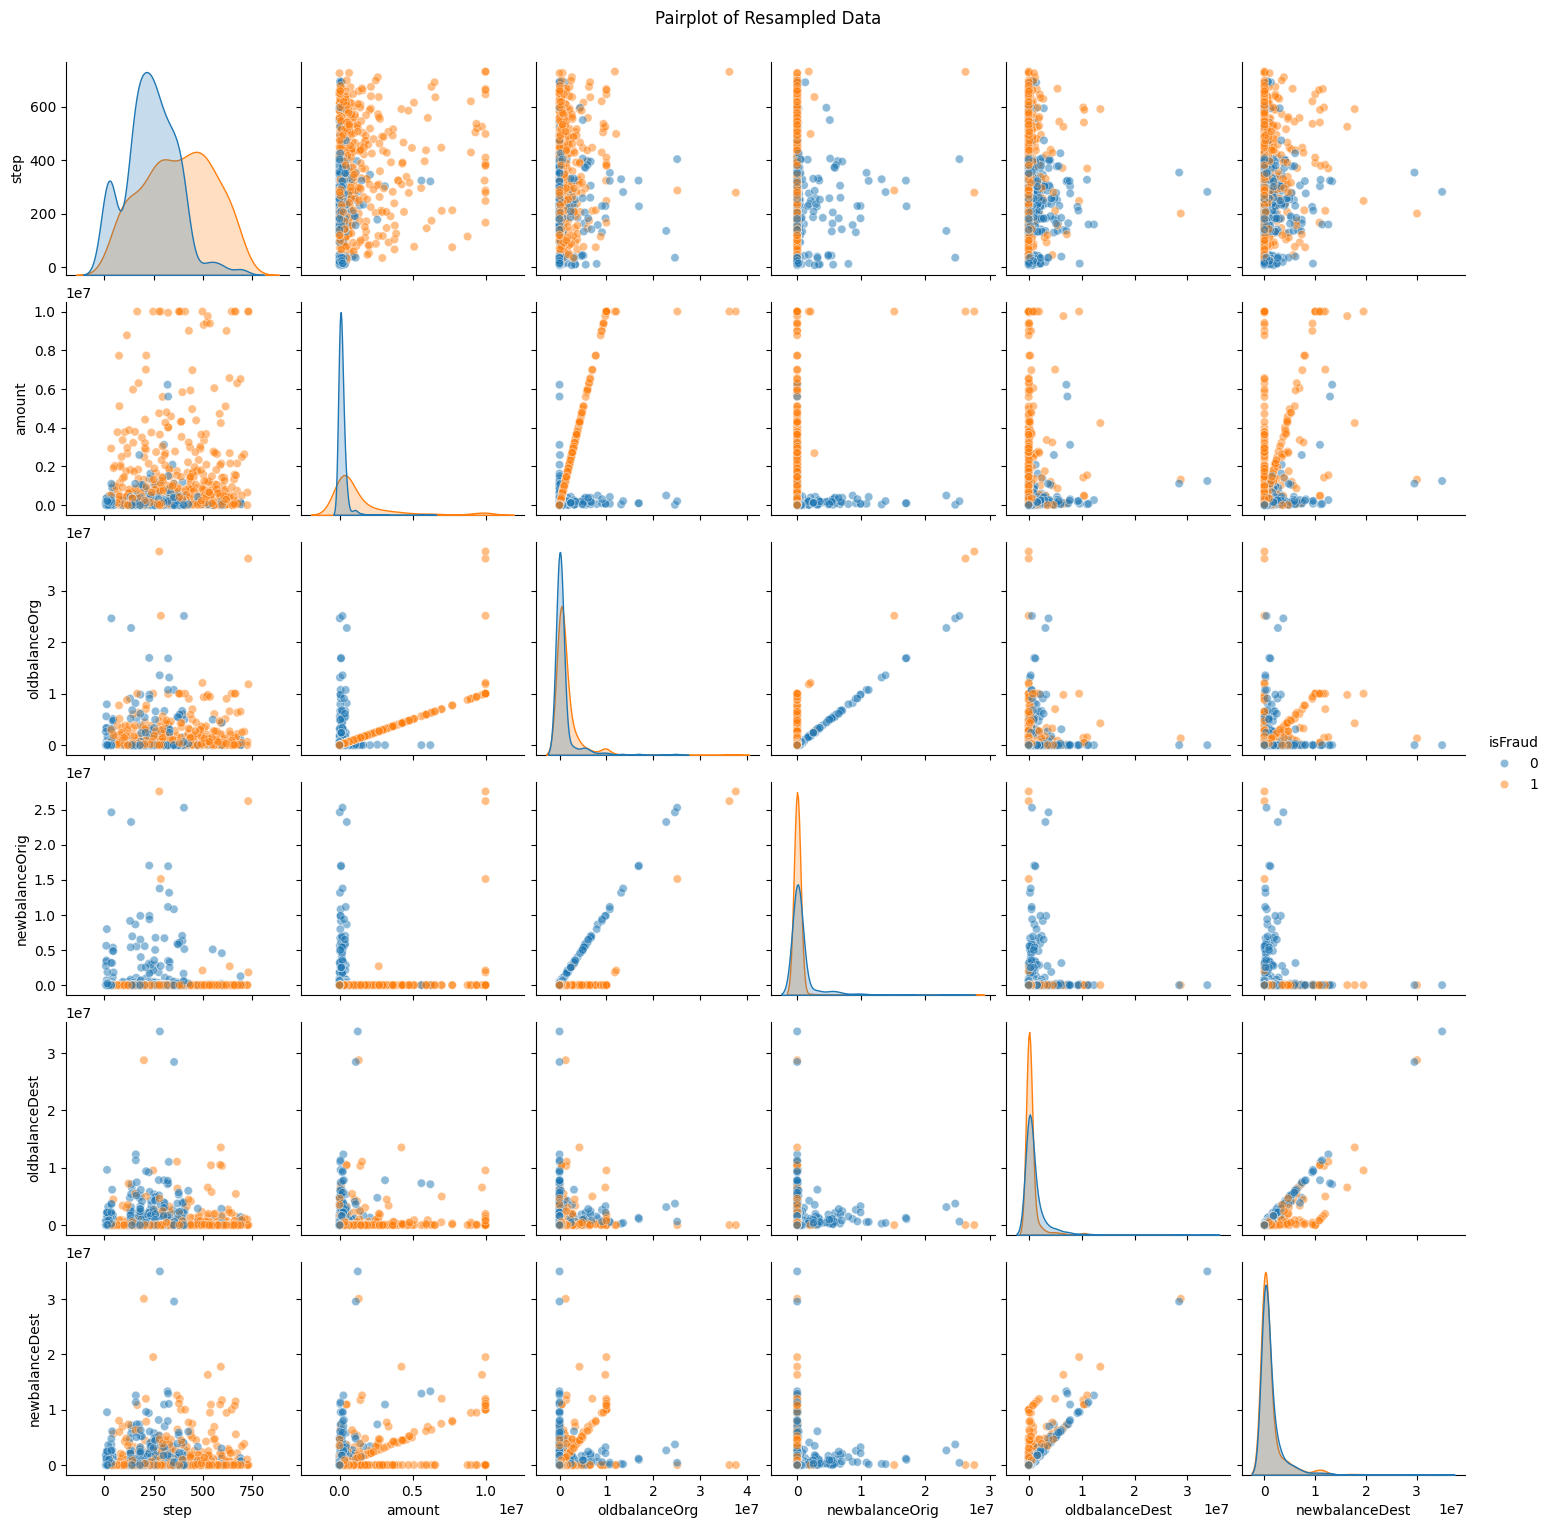

In [29]:
df_pairplot = X_sm.copy()
df_pairplot['isFraud'] = y_sm.values
numeric_cols = df_pairplot.select_dtypes(include=['int64', 'float64']).columns
df_pairplot_sample = df_pairplot.sample(n=1000, random_state=42)
sns.pairplot(df_pairplot_sample[numeric_cols], hue='isFraud', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Resampled Data', y=1.02)
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=3, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}:\n---------------------")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression:
---------------------
Accuracy: 0.9527
              precision    recall  f1-score   support

           0       0.95      0.95      0.95   1270837
           1       0.95      0.95      0.95   1270926

    accuracy                           0.95   2541763
   macro avg       0.95      0.95      0.95   2541763
weighted avg       0.95      0.95      0.95   2541763


Decision Tree:
---------------------
Accuracy: 0.9997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270837
           1       1.00      1.00      1.00   1270926

    accuracy                           1.00   2541763
   macro avg       1.00      1.00      1.00   2541763
weighted avg       1.00      1.00      1.00   2541763


Random Forest:
---------------------
Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270837
           1       1.00      1.00      1.00   1270926

    accurac

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:12:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost:
---------------------
Accuracy: 0.9987
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270837
           1       1.00      1.00      1.00   1270926

    accuracy                           1.00   2541763
   macro avg       1.00      1.00      1.00   2541763
weighted avg       1.00      1.00      1.00   2541763



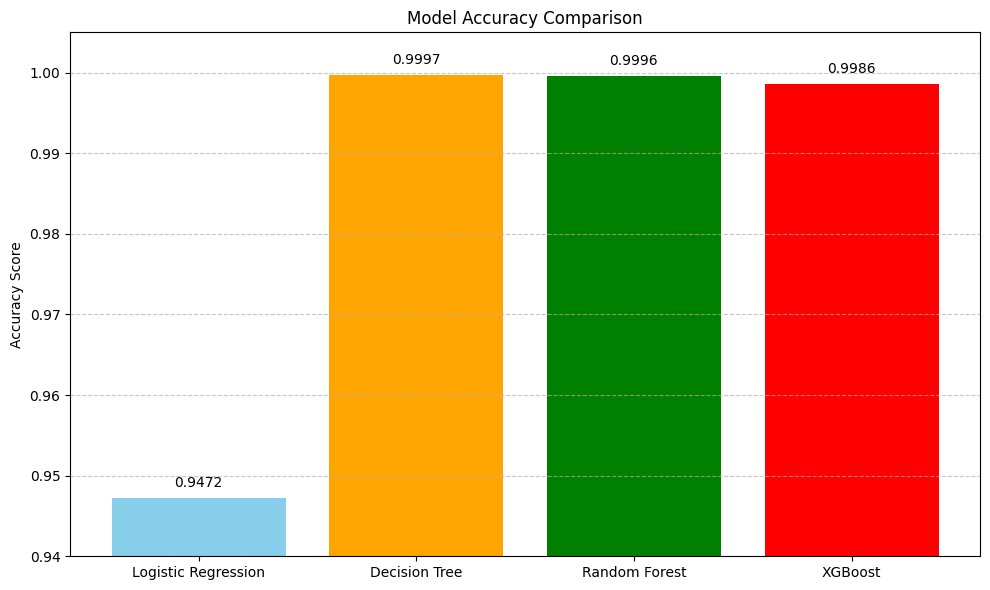

In [32]:
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
accuracy_scores = [0.9472, 0.9997, 0.9996, 0.9986]
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracy_scores, color=['skyblue', 'orange', 'green', 'red'])
for bar, acc in zip(bars, accuracy_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.001, f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0.94, 1.005)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

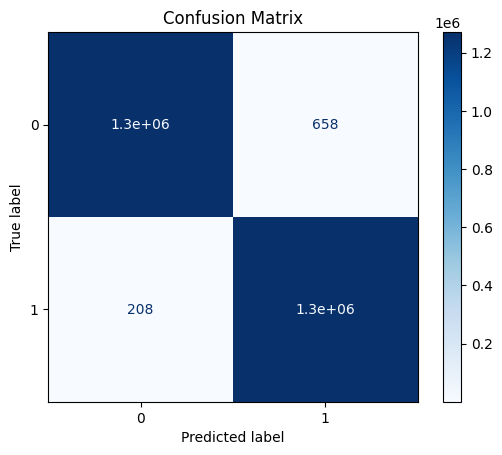

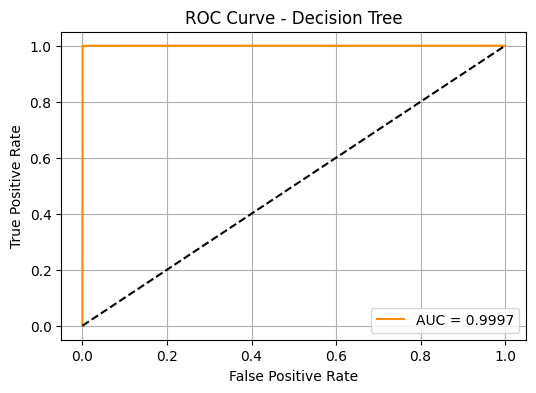

In [33]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
best_model = dt_model
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [34]:
joblib.dump(model, "best_model.pkl")
print("Model saved to best_model.pkl")

Model saved to best_model.pkl


In [35]:
best_model = joblib.load("best_model.pkl")

In [36]:
best_model = joblib.load("best_model.pkl")

def get_float(prompt):
    while True:
        try:
            return float(input(prompt))
        except ValueError:
            print("Please enter a valid number.")

def get_int(prompt):
    while True:
        try:
            return int(input(prompt))
        except ValueError:
            print("Please enter a valid integer.")

def get_transaction_type():
    valid_types = ['CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
    while True:
        t = input(f"Enter transaction type ({', '.join(valid_types)}): ").upper()
        if t in valid_types:
            return [1 if t == vt else 0 for vt in valid_types]
        else:
            print("Invalid type. Please choose from the given options.")

step = get_int("Enter step (integer): ")
amount = get_float("Enter transaction amount: ")
oldbalanceOrg = get_float("Enter the balance of sender before transaction: ")
newbalanceOrig = get_float("Enter the balance of sender after transaction: ")
oldbalanceDest = get_float("Enter the balance of receiver before transaction: ")
newbalanceDest = get_float("Enter the balance of receiver after transaction: ")
type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER = get_transaction_type()

input_features = np.array([[step, amount, oldbalanceOrg, newbalanceOrig,
                            oldbalanceDest, newbalanceDest,
                            type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER]])

prediction = best_model.predict(input_features)[0]
proba = best_model.predict_proba(input_features)[0]

print("\nPrediction:", "Fraud" if prediction == 1 else "Not Fraud")
print(f"Confidence: {proba[1]*100:.2f}% for Fraud, {proba[0]*100:.2f}% for Not Fraud")

Enter step (integer): 100
Enter transaction amount: 5000
Enter the balance of sender before transaction: 10000
Enter the balance of sender after transaction: 5000
Enter the balance of receiver before transaction: 2000
Enter the balance of receiver after transaction: 7000
Enter transaction type (CASH_OUT, DEBIT, PAYMENT, TRANSFER): TRANSFER

Prediction: Not Fraud
Confidence: 0.00% for Fraud, 100.00% for Not Fraud
